# `TA` homogenisation: options for the 2016 sensor change

**notebook version**: `1` (28 Jul 2026)

## ℹ️ About this notebook

`30_PRODUCTS/02_METEO_TA_2004-2025.ipynb` corrects the 21 January 2016 sensor change with a single
constant, and states in *What the correction does not fix* that a constant cannot remove the part
of the change that acts in daylight. This notebook asks whether a better construction exists. It
**computes and exports nothing**; it evaluates candidates and records which one the evidence
supports, so that a change to `02` is made on measurements rather than on preference.

**The question that prompted it.** NABEL at 49 m is aspirated, sits on the same tower, and runs to
the end of 2018. It agrees with the MeteoSwiss reference more closely than the 47 m series does,
and it passes through January 2016 without a step. That suggests substituting it for the early
years and switching to the homogenised 47 m afterwards.

**Four candidates are scored**, all against MeteoSwiss Lägern, which enters none of the
corrections:

- **A** the series as measured, no correction — the baseline;
- **B** a constant offset on the pre-2016 era — what the product did up to version 6 of `02`;
- **C** NABEL 49 m until the end of its record, then the homogenised 47 m — the proposal above;
- **D** a per-era radiation term fitted against NABEL, which removes the difference between the two
  radiation shields instead of only the difference between their zero points.

**What it concludes.** `C` does not remove the daytime step, it moves it: the 47 m shields differ
from an aspirated one by more than they differ from each other, so splicing at the end of the
NABEL record places the whole shield difference at a **new** join in 2019, larger than the one it
removes at 2016. `D` removes most of it with no new join, and survives the three objections that
had this option rejected before: it is validated on years NABEL never saw, it is unaffected by the
2022 and 2025 events at the site, and it does not depend on gap-filled radiation.

***

## 📇 Data sources

**Files**

- `30_PRODUCTS/02_METEO_TA_GAPFILLED_2004-2025.parquet` — the TA product. Its **measured** records
  (`FLAG_TA_T1_47_1_ISFILLED == 0`) are the 47 m series used here, already carrying the screening
  and the 2012 corrections applied in `02`. The break date and the homogenisation constant are
  read back out of its columns rather than written down here
- `30_PRODUCTS/01_METEO_SW_IN_GAPFILLED_2004-2025.parquet` — incoming shortwave **at the tower**,
  the driver of the radiation term of candidate `D`
- `10_REFERENCE/MeteoSwiss_LAE_30MIN_2004-2025.parquet` — MeteoSwiss Lägern, 2.5 km, 845 m. The
  **scoring** reference. It enters no correction in this notebook, which is what makes the scores
  a test rather than a restatement of a fit

**Database**

- `TA_NABEL_T1_49_1` — NABEL, 49 m, same tower, aspirated, 2005 to the end of 2018. The
  **fitting** reference of candidate `D`. It is not held in any file, so it is downloaded from
  InfluxDB as `02` downloads it. Unlike `TA_T1_47_1` it exists under **one** data version only
  (`meteoscreening_diive`), so there is nothing to merge and no `mst`/`diive` boundary in it

Every candidate is fitted against NABEL and scored against MeteoSwiss. The two are independent
instruments run by different institutions, so no score in this notebook is reported by the series
that produced the correction it judges.

## ⏱️ Timestamp convention

The two products and this notebook work on `TIMESTAMP_MID`. The database returns `TIMESTAMP_END`,
so the NABEL download passes through `TimestampSanitizer(output_middle_timestamp=True)` as in
`02`; the MeteoSwiss reference is stored on `TIMESTAMP_END` and is shifted back 15 minutes. Both
conversions are the ones `02` performs, and a disagreement would show up as a correlation maximum
away from lag zero, which is asserted below.

***

## ⚙️ Settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389   # CH-LAE

DATADIR = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO"

# The TA product this notebook evaluates, and the SW_IN product that drives candidate D.
TA_FILE = r"30_PRODUCTS\02_METEO_TA_GAPFILLED_2004-2025.parquet"
TA_COL = "TA_T1_47_1_gfXG"
TA_HOMOG_COL = "TA_T1_47_1_HOMOGENIZED_gfXG"
TA_FLAG_COL = "FLAG_TA_T1_47_1_ISFILLED"
TA_SOURCE_COL = "FLAG_TA_T1_47_1_SOURCE"
SWIN_FILE = r"30_PRODUCTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet"
SWIN_COL = "SW_IN_T1_47_1_gfXG"
SWIN_FLAG_COL = "FLAG_SW_IN_T1_47_1_ISFILLED"

# The scoring reference. No correction below is fitted against it.
REF_FILE = r"10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet"
REFCOL = "TA_LAE_MS"
REFCOL_SW = "SW_IN_LAE_MS"

# The fitting reference, from the database.
NABEL_COL = "TA_NABEL_T1_49_1"

# Comparison windows. Three complete years either side of each boundary, chosen so that a window
# never straddles a boundary of any candidate - candidate C has a second one at its 2019 join, and
# a window spanning it would report the two steps mixed together.
N_WINDOW_YEARS = 3
FIRST_YEAR = 2005     # the tower record's first complete year

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import textwrap

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")


# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    fig.supxlabel(textwrap.fill(f"Figure - {text}", width), fontsize=9, ha='left', x=0.005)

Last run: 2026-07-28 17:47:18
diive version: v0.91.0


***

## ⬇️ Data

### The two products and the scoring reference

The 47 m series is taken as **measured records only**. A candidate is a way of correcting a
measurement, so a modelled record would only report what the gap-filler was told about the eras.

In [3]:
ta_product = pd.read_parquet(Path(DATADIR) / TA_FILE)
swin_product = pd.read_parquet(Path(DATADIR) / SWIN_FILE)
reference = pd.read_parquet(Path(DATADIR) / REF_FILE)[[REFCOL, REFCOL_SW]]
reference.index = reference.index - pd.Timedelta(minutes=15)   # TIMESTAMP_END -> TIMESTAMP_MID
reference.index.name = ta_product.index.name

for _name, _df in [('TA product', ta_product), ('SW_IN product', swin_product),
                   ('MeteoSwiss reference', reference)]:
    print(f"{_name:22s} {len(_df):>7,} records  {_df.index[0]:%Y-%m-%d} to {_df.index[-1]:%Y-%m-%d}"
          f"  columns: {list(_df.columns)}")

# The break and the constant are read back out of the product, so this notebook cannot drift away
# from the notebook it is evaluating. BREAK is the first record the source flag assigns to the
# CS215 era; OFFSET is the shift the product actually applied.
BREAK = ta_product.index[ta_product[TA_SOURCE_COL] == 0][0]
OFFSET = float((ta_product[TA_HOMOG_COL] - ta_product[TA_COL]).max())
print(f"\nread back from the product:  BREAK = {BREAK}   OFFSET = {OFFSET:+.4f} degC")
assert 1.0 < OFFSET < 1.6, f"the product's offset {OFFSET:.3f} degC is not what this notebook expects"
assert BREAK.year == 2016, "the product's break is not in 2016"

TA product             385,728 records  2004-01-01 to 2025-12-31  columns: ['TA_T1_47_1_gfXG', 'FLAG_TA_T1_47_1_ISFILLED', 'TA_T1_47_1_HOMOGENIZED_gfXG', 'FLAG_TA_T1_47_1_SOURCE']
SW_IN product          385,728 records  2004-01-01 to 2025-12-31  columns: ['SW_IN_T1_47_1_gfXG', 'FLAG_SW_IN_T1_47_1_ISFILLED']
MeteoSwiss reference   384,241 records  2004-02-01 to 2026-01-01  columns: ['TA_LAE_MS', 'SW_IN_LAE_MS']

read back from the product:  BREAK = 2016-01-21 14:15:00   OFFSET = +1.3197 degC


### NABEL from the database

In [4]:
%%time

dbc = InfluxIO(dirconf=DIRCONF)

# One data version only. `TA_T1_47_1` exists under both `meteoscreening_mst` and
# `meteoscreening_diive` and 02 merges them; NABEL does not, so there is nothing to merge here -
# and no screening boundary inside the series that every fit below is anchored on. The absence is
# checked rather than assumed, because an empty download and a merged one look the same afterwards.
nabel, _, _ = dbc.download(
    bucket='ch-lae_processed', measurements=['TA'], fields=[NABEL_COL],
    start='2004-01-01 00:00:01', stop='2026-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive')
nabel = TimestampSanitizer(data=nabel, output_middle_timestamp=True,
                           nominal_freq=REQUIRED_TIME_RESOLUTION).get()

_mst_probe, _, _ = dbc.download(
    bucket='ch-lae_processed', measurements=['TA'], fields=[NABEL_COL],
    start='2004-01-01 00:00:01', stop='2022-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_mst')
print(f"{NABEL_COL} under meteoscreening_mst: {len(_mst_probe)} records")
assert len(_mst_probe) == 0, (
    f"{NABEL_COL} now also exists under meteoscreening_mst - it would have to be merged in as 02 "
    f"merges the 47 m series, and the eras either side of that boundary checked")

print(f"NABEL: {nabel[NABEL_COL].notna().sum():,} records, "
      f"{nabel[NABEL_COL].dropna().index[0]:%Y-%m-%d} to {nabel[NABEL_COL].dropna().index[-1]:%Y-%m-%d}")

> Reading configuration files was successful.

v Connection to database works.

> DOWNLOADING from bucket ch-lae_processed: variables ['TA_NABEL_T1_49_1'] from measurements 
['TA'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['TA_NABEL_T1_49_1'] from measurements 
['TA'], data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 
(timezone offset to UTC 1)

> No data found for the requested query.

TA_NABEL_T1_49_1 under meteoscreening_mst: 0 records
NABEL: 262,403 records, 2004-01-01 to 2018-12-31
CPU times: total: 7.91 s
Wall time: 10.3 s


### One frame, and the checks the rest of the notebook rests on

In [5]:
# Reindexed onto the product's own index before anything else: the MeteoSwiss reference runs a
# few hours past the end of 2025, and a plain concat carries those rows in as a 2026 that holds no
# measurement and no product - and that would then appear in every groupby by year below.
d = pd.concat([ta_product, swin_product[[SWIN_COL, SWIN_FLAG_COL]], nabel[[NABEL_COL]], reference],
              axis=1).reindex(ta_product.index).loc[str(FIRST_YEAR):]
assert d.index.equals(ta_product.index[ta_product.index.year >= FIRST_YEAR]), \
    "the working frame is not on the product's index"

# Measured 47 m records only.
d['measured'] = d[TA_COL].where(d[TA_FLAG_COL] == 0)

# Night from potential radiation: no measurement enters the day/night split.
_potrad = dv.variables.potrad(timestamp_index=d.index, lat=SITE_LAT, lon=SITE_LON,
                              utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
d['night'] = (_potrad <= 0).to_numpy()
d['era'] = np.where(d.index < BREAK, 'MP101A', 'CS215')

NABEL_LAST_YEAR = int(d[NABEL_COL].dropna().index[-1].year)
print(f"{len(d):,} records {d.index[0]:%Y-%m-%d} to {d.index[-1]:%Y-%m-%d}")
print(f"measured 47 m: {d['measured'].notna().sum():,}   NABEL: {d[NABEL_COL].notna().sum():,} "
      f"(last full year {NABEL_LAST_YEAR})   MeteoSwiss: {d[REFCOL].notna().sum():,}")
print(f"night share: {d['night'].mean() * 100:.0f} %")

assert 0.4 < d['night'].mean() < 0.6, "the night mask covers an implausible share of the record"
assert d[NABEL_COL].notna().sum() > 200_000, "the NABEL download is much smaller than expected"
assert NABEL_LAST_YEAR < BREAK.year + 4, "NABEL now reaches further than this notebook assumes"

# The timestamp alignment of both references, checked rather than assumed. A reference shifted by
# one bin would change every number below and nothing would look wrong.
_probe = d[['measured', REFCOL, NABEL_COL]].dropna()
for _col in (REFCOL, NABEL_COL):
    _lags = {_lag: _probe['measured'].corr(_probe[_col].shift(_lag)) for _lag in (-2, -1, 0, 1, 2)}
    _best = max(_lags, key=_lags.get)
    print(f"  {_col}: correlation by lag " + "  ".join(f"{k:+d}:{v:.4f}" for k, v in _lags.items()))
    assert _best == 0, f"{_col} correlates best at lag {_best}, not 0 - the timestamps are misaligned"

368,160 records 2005-01-01 to 2025-12-31
measured 47 m: 364,143   NABEL: 244,895 (last full year 2018)   MeteoSwiss: 367,889
night share: 48 %
  TA_LAE_MS: correlation by lag -2:0.9888  -1:0.9905  +0:0.9910  +1:0.9895  +2:0.9869
  TA_NABEL_T1_49_1: correlation by lag -2:0.9930  -1:0.9951  +0:0.9958  +1:0.9941  +2:0.9913


***

## 1️⃣ Why the question arises

Three statements motivate the proposal, and all three hold: NABEL agrees with MeteoSwiss more
closely than the 47 m series does, it scatters less around it, and it carries **no** step across
January 2016 — in daylight as well as at night. Being aspirated, it has no radiation shield to be
in error, which is why.

In [6]:
# Everything is compared on the window where all three instruments are present, so that a
# difference between them cannot be a difference in which records each one covers.
common = d.dropna(subset=['measured', NABEL_COL, REFCOL]).copy()
common['homogenised'] = common['measured'] + np.where(common.index < BREAK, OFFSET, 0.0)
print(f"Common overlap: {len(common):,} half-hours, "
      f"{common.index[0]:%Y-%m} to {common.index[-1]:%Y-%m}")

_rows = []
for _label, _col in [('47 m as measured', 'measured'), ('47 m homogenised', 'homogenised'),
                     ('NABEL 49 m (aspirated)', NABEL_COL)]:
    _r = common[_col] - common[REFCOL]
    _n, _dy = common['night'].to_numpy(), (~common['night']).to_numpy()
    _rows.append({'series': _label, 'mean (degC)': _r.mean(), 'SD (degC)': _r.std(),
                  'night mean': _r[_n].mean(), 'day mean': _r[_dy].mean(),
                  'r': common[_col].corr(common[REFCOL])})
agreement = pd.DataFrame(_rows).set_index('series')
tabcap("how each candidate series agrees with MeteoSwiss over the window where the 47 m sensor, NABEL and the reference are all present. NABEL scatters least around the reference, and its night and day means are closest to each other")
display(agreement.round(3))

# The premise, asserted. If NABEL stopped being the closer of the two, the proposal below would
# have no starting point and this notebook would be answering a question nobody had.
assert agreement.loc['NABEL 49 m (aspirated)', 'SD (degC)'] \
       < agreement.loc['47 m homogenised', 'SD (degC)'], \
    "NABEL no longer scatters less around MeteoSwiss than the 47 m series - re-read section 1"

Common overlap: 241,740 half-hours, 2005-01 to 2018-12
Table - how each candidate series agrees with MeteoSwiss over the window where the 47 m sensor,
NABEL and the reference are all present. NABEL scatters least around the reference, and its night
and day means are closest to each other



,mean (degC),SD (degC),night mean,day mean,r
series,,,,,
47 m as measured,0.291,1.118,0.045,0.517,0.991
47 m homogenised,1.329,0.919,1.084,1.554,0.994
NABEL 49 m (aspirated),0.928,0.853,0.851,0.997,0.994


***

## 2️⃣ The four candidates

`A` and `B` exist already: the measured column and the homogenised column of the product. `C` is
the proposal. `D` is built in section 4️⃣ and is placed here so that the definitions sit together.

A candidate is only interesting if it is homogeneous across **every** boundary it has, not only
across the one it was designed for. `C` has two — the 2016 sensor change and its own join at the
end of the NABEL record — which is the whole of what section 3️⃣ is about.

In [7]:
# The comparison windows, derived from the break and from the extent of NABEL rather than written
# down. Each window sits inside one segment of every candidate.
BREAK_PRE = list(range(BREAK.year - N_WINDOW_YEARS, BREAK.year))            # 2013-2015
BREAK_POST = list(range(BREAK.year, BREAK.year + N_WINDOW_YEARS))           # 2016-2018
JOIN_PRE = list(range(NABEL_LAST_YEAR - N_WINDOW_YEARS + 1, NABEL_LAST_YEAR + 1))   # 2016-2018
JOIN_POST = list(range(NABEL_LAST_YEAR + 1, NABEL_LAST_YEAR + 1 + N_WINDOW_YEARS))  # 2019-2021
print(f"2016 boundary: {BREAK_PRE} against {BREAK_POST}")
print(f"2019 join    : {JOIN_PRE} against {JOIN_POST}")

# The break year holds no measurement before the break, so a window may start at it without
# mixing the two sensors. That is asserted in 02 and re-asserted here, because BREAK_POST relies
# on it and a mid-year break would make every number in this notebook wrong by a few weeks.
_bk = d.loc[d.index.year == BREAK.year, 'measured']
assert _bk[_bk.index < BREAK].notna().sum() == 0, \
    f"{BREAK.year} holds measurements before the break, so a window starting at it mixes the eras"
assert set(BREAK_POST) & set(JOIN_PRE), "the two boundaries no longer share the CS215 window"

2016 boundary: [2013, 2014, 2015] against [2016, 2017, 2018]
2019 join    : [2016, 2017, 2018] against [2019, 2020, 2021]


***

## 3️⃣ Candidate C: the step is moved, not removed

Splicing NABEL in until the end of 2018 does remove the 2016 step — it removes it completely,
because NABEL never had one. But the series then has to change instrument again in 2019, from an
**aspirated** sensor to a **passively shielded** one, and that is a larger change than the one
between the two passively shielded sensors of 2016.

In [8]:
candidates = pd.DataFrame(index=d.index)
candidates['A as measured'] = d['measured']
candidates['B constant offset'] = d['measured'] + np.where(d.index < BREAK, OFFSET, 0.0)
candidates['C NABEL to 2018'] = np.where(d.index.year <= NABEL_LAST_YEAR,
                                         d[NABEL_COL], candidates['B constant offset'])


def boundary_step(values, years_before, years_after, window, min_records=500):
    """Mean residual against MeteoSwiss over two year sets, within `window`, and the step between.

    Raises when either side is thinner than `min_records`. The masks are intersected, so a window
    that misses one side is possible, and a mean over a handful of half-hours would be printed in
    the same column as a mean over three years.
    """
    _r = (values - d[REFCOL]).dropna()
    _w = window.reindex(_r.index).fillna(False).to_numpy()
    _a = _w & _r.index.year.isin(years_before)
    _b = _w & _r.index.year.isin(years_after)
    if _a.sum() < min_records or _b.sum() < min_records:
        raise ValueError(f"too few records: {_a.sum()} in {years_before}, {_b.sum()} in "
                         f"{years_after}, need {min_records} in each")
    return _r[_a].mean(), _r[_b].mean(), _r[_b].mean() - _r[_a].mean()

In [9]:
# The guard guards. An empty year set and a single-day window are both fed to it; neither fails on
# its own, and both would be reported as a step.
_night_mask = pd.Series(d['night'].to_numpy(), index=d.index)
_one_day = pd.Series(d.index.normalize() == pd.Timestamp('2014-04-10'), index=d.index)
for _label, _window, _a, _b in [
        ("a period the record does not cover", _night_mask, [1999], JOIN_POST),
        ("a window of one calendar day", _one_day, [2014], [2018])]:
    try:
        boundary_step(candidates['B constant offset'], _a, _b, _window)
    except ValueError as _e:
        print(f"boundary_step raises on {_label}: {_e}")
    else:
        raise AssertionError(f"boundary_step accepted {_label}")

boundary_step raises on a period the record does not cover: too few records: 0 in [1999], 24609 in [2019, 2020, 2021], need 500 in each


boundary_step raises on a window of one calendar day: too few records: 48 in [2014], 0 in [2018], need 500 in each


In [10]:
_day_mask = pd.Series((~d['night']).to_numpy(), index=d.index)

_rows = []
for _cand in candidates.columns:
    for _bname, _ba, _bb in [(f'{BREAK.year} sensor change', BREAK_PRE, BREAK_POST),
                             (f'{NABEL_LAST_YEAR + 1} join of candidate C', JOIN_PRE, JOIN_POST)]:
        _row = {'candidate': _cand, 'boundary': _bname}
        for _wname, _wmask in [('night', _night_mask), ('day', _day_mask)]:
            _row[f'{_wname} (degC)'] = boundary_step(candidates[_cand], _ba, _bb, _wmask)[2]
        _rows.append(_row)
step_table = pd.DataFrame(_rows).set_index(['candidate', 'boundary'])
tabcap("the step each candidate carries at both boundaries: the 2016 sensor change, and the join candidate C creates at the end of the NABEL record. A candidate has to be homogeneous across every boundary it has, not only the one it was designed for")
display(step_table.round(2))

_c16 = abs(step_table.loc[('C NABEL to 2018', f'{BREAK.year} sensor change'), 'day (degC)'])
_c19 = abs(step_table.loc[('C NABEL to 2018', f'{NABEL_LAST_YEAR + 1} join of candidate C'), 'day (degC)'])
_b16 = abs(step_table.loc[('B constant offset', f'{BREAK.year} sensor change'), 'day (degC)'])
print(f"\nCandidate C removes a daytime step of {_b16:.2f} degC at {BREAK.year} "
      f"(leaving {_c16:.2f}) and creates one of {_c19:.2f} degC at {NABEL_LAST_YEAR + 1}.")

# The finding of this section, asserted so that it cannot quietly stop being true.
assert _c16 < _b16, "candidate C no longer improves the 2016 boundary - re-read this section"
assert _c19 > _b16, (
    "candidate C's own join is no longer the larger step - the conclusion of this section rests "
    "on it being larger and must be re-derived")

Table - the step each candidate carries at both boundaries: the 2016 sensor change, and the join
candidate C creates at the end of the NABEL record. A candidate has to be homogeneous across every
boundary it has, not only the one it was designed for



night (degC)  day (degC)
candidate         boundary                                          
A as measured     2016 sensor change                1.29        1.77
                  2019 join of candidate C          0.04       -0.16
B constant offset 2016 sensor change               -0.03        0.45
                  2019 join of candidate C          0.04       -0.16
C NABEL to 2018   2016 sensor change               -0.09       -0.03
                  2019 join of candidate C          0.27        0.67


Candidate C removes a daytime step of 0.45 degC at 2016 (leaving 0.03) and creates one of 0.67 degC at 2019.


The 2016 step is removed, and a larger one appears in 2019. The reason is physical and is not
specific to this site: the two 47 m sensors are both passively shielded and differ from each other
only in how much each one warms in sun, while NABEL is aspirated and differs from **both** by the
whole of that error. Splicing at the end of the NABEL record therefore takes a small difference at
2016 and replaces it with a large one at 2019 — and moves it into the part of the record that has
no independent tower measurement left to check it against.

Two further costs, neither of which needs a measurement to state. A column named `TA_T1_47_1`
would describe a different institution's instrument for fourteen of twenty-one years; and NABEL
ends, so the construction can never cover the record.

**Candidate C is rejected.** It is kept in the scorecard because the reason it fails is the same
mechanism candidate `D` exploits.

***

## 4️⃣ Candidate D: the difference between the two shields

The 2016 step is the sum of two errors: a **zero-point** error in the old analog chain, which acts
day and night, and a **radiative** error, which differs between the two shields and acts only in
sun. `02` measures and removes the first. The second is what is left.

NABEL is the instrument that can measure it. It is aspirated, so its own radiative error is
negligible, and it overlaps **both** eras — eleven years of the MP101A and three of the CS215. The
difference `47 m − NABEL`, taken as a function of the tower's own incoming shortwave, is therefore
the shield response of whichever sensor was in place.

In [11]:
# The fit set: measured 47 m, measured NABEL, and the tower's own SW_IN.
fitset = d.dropna(subset=['measured', NABEL_COL, SWIN_COL]).copy()
fitset['bias'] = fitset['measured'] - fitset[NABEL_COL]
print(f"fit rows: {len(fitset):,}  ({fitset.index[0]:%Y-%m} to {fitset.index[-1]:%Y-%m})")
print(fitset.groupby('era').size().to_string())
assert set(fitset['era']) == {'MP101A', 'CS215'}, "the fit set does not cover both eras"
assert fitset.groupby('era').size().min() > 20_000, "one era has too few records to fit"


def shield_basis(sw, order):
    """Polynomial design matrix in incoming shortwave, scaled to kW m-2 so powers stay conditioned."""
    _x = np.asarray(sw, dtype=float) / 1000.0
    return np.column_stack([_x ** _k for _k in range(1, order + 1)] + [np.ones(len(_x))])


def fit_shield(frame, order):
    """Least-squares shield response per era. Raises on an era the frame does not cover."""
    _coef = {}
    for _era in ('MP101A', 'CS215'):
        _g = frame[frame['era'] == _era]
        if len(_g) < 5_000:
            raise ValueError(f"era {_era} holds {len(_g)} rows, too few to fit a shield response")
        _beta, *_ = np.linalg.lstsq(shield_basis(_g[SWIN_COL], order), _g['bias'].to_numpy(),
                                    rcond=None)
        _coef[_era] = _beta
    return _coef

fit rows: 241,792  (2005-01 to 2018-12)
era
CS215      51600
MP101A    190192


In [12]:
# The guard guards: an era the frame does not cover must raise, not return a fit of one era twice.
try:
    fit_shield(fitset[fitset['era'] == 'MP101A'], 2)
except ValueError as _e:
    print(f"fit_shield raises when an era is absent: {_e}")
else:
    raise AssertionError("fit_shield accepted a frame holding only one era")

fit_shield raises when an era is absent: era CS215 holds 0 rows, too few to fit a shield response


### How many terms the CS215 era supports

The MP101A era has eleven years of overlap with NABEL and the CS215 era has three, so the order of
the polynomial is set by what the **shorter** era can carry. Two criteria decide it, because they
catch different failures:

- **held-out error** — each of the three NABEL years of the CS215 era is left out in turn and
  predicted from the other two. This asks whether the terms generalise to a year they were not
  fitted on;
- **largest departure from the era's own binned means** — the fitted curve is compared against the
  bin averages it is supposed to describe. A record-weighted error cannot see this: most
  half-hours sit at low radiation, so a curve can be wrong by several tenths of a degree in the
  brightest conditions and barely move an RMSE. Those are the conditions daily maxima come from.

The order taken is the **smallest** that satisfies both.

In [13]:
# Radiation bins the fitted curves are held against. Wide at the top, where half-hours are few.
SHIELD_BINS = [0, 25, 75, 150, 250, 350, 450, 550, 650, 800, 1200]
RMSE_TOLERANCE = 0.005   # degC, how close to the best held-out error still counts as equal
SHAPE_TOLERANCE = 0.15   # degC, largest allowed departure from an era's own binned means


def binned_response(frame):
    """Mean bias, mean radiation and record count per radiation bin, for one era.

    The mean radiation of each bin is returned rather than the bin centre: the top bin spans
    400 W m-2 and its records sit near its lower edge, so plotting or testing it at the centre
    would place it where nothing was measured.
    """
    _g = frame.groupby(pd.cut(frame[SWIN_COL], SHIELD_BINS), observed=False)
    return pd.DataFrame({'sw': _g[SWIN_COL].mean(), 'bias': _g['bias'].mean(),
                         'records': _g['bias'].size()})


_rows = []
for _order in (1, 2, 3, 4):
    _cs = fitset[fitset['era'] == 'CS215']
    _errs = []
    for _yr in sorted(set(_cs.index.year)):
        _tr, _te = _cs[_cs.index.year != _yr], _cs[_cs.index.year == _yr]
        if len(_te) < 5_000 or len(_tr) < 5_000:
            continue
        _beta, *_ = np.linalg.lstsq(shield_basis(_tr[SWIN_COL], _order), _tr['bias'].to_numpy(),
                                    rcond=None)
        _errs.append(np.sqrt(np.mean(
            (shield_basis(_te[SWIN_COL], _order) @ _beta - _te['bias'].to_numpy()) ** 2)))
    _shape = max(
        np.abs(shield_basis(binned_response(_g)['sw'], _order) @ fit_shield(fitset, _order)[_era]
               - binned_response(_g)['bias']).max()
        for _era, _g in fitset.groupby('era'))
    _rows.append({'order': _order, 'held-out years': len(_errs),
                  'leave-one-year-out RMSE (degC)': np.mean(_errs),
                  'largest departure from the binned means (degC)': _shape})
order_choice = pd.DataFrame(_rows).set_index('order')
tabcap("the two criteria the polynomial order is chosen on. The held-out error asks whether the terms generalise to a year they were not fitted on; the departure from the binned means asks whether the curve has the right shape, which a record-weighted error cannot see")
display(order_choice.round(4))

_rmse = order_choice['leave-one-year-out RMSE (degC)']
_shape = order_choice['largest departure from the binned means (degC)']
_ok = order_choice.index[(_rmse <= _rmse.min() + RMSE_TOLERANCE) & (_shape <= SHAPE_TOLERANCE)]
assert len(_ok) > 0, (
    f"no order tried is both within {RMSE_TOLERANCE} degC of the best held-out error and within "
    f"{SHAPE_TOLERANCE} degC of the binned means - the polynomial is the wrong family here")
SHIELD_ORDER = int(_ok.min())
print(f"Chosen order: {SHIELD_ORDER} - the smallest within {RMSE_TOLERANCE} degC of the best "
      f"held-out error ({_rmse.min():.4f}) and within {SHAPE_TOLERANCE} degC of the binned means.")
for _o in order_choice.index:
    _why = []
    if _rmse[_o] > _rmse.min() + RMSE_TOLERANCE:
        _why.append(f"held-out error {_rmse[_o]:.4f}")
    if _shape[_o] > SHAPE_TOLERANCE:
        _why.append(f"departure from the binned means {_shape[_o]:.2f} degC")
    if _why:
        print(f"  order {_o}: rejected on " + " and on ".join(_why))
    elif _o == SHIELD_ORDER:
        print(f"  order {_o}: taken")
    else:
        print(f"  order {_o}: acceptable as well, and carries more terms than needed")

Table - the two criteria the polynomial order is chosen on. The held-out error asks whether the
terms generalise to a year they were not fitted on; the departure from the binned means asks whether
the curve has the right shape, which a record-weighted error cannot see



,held-out years,leave-one-year-out RMSE (degC),largest departure from the binned means (degC)
order,,,
1,3,0.5935,0.5308
2,3,0.5621,0.1076
3,3,0.5606,0.0642
4,3,0.5600,0.0662


Chosen order: 2 - the smallest within 0.005 degC of the best held-out error (0.5600) and within 0.15 degC of the binned means.
  order 1: rejected on held-out error 0.5935 and on departure from the binned means 0.53 degC
  order 2: taken
  order 3: acceptable as well, and carries more terms than needed
  order 4: acceptable as well, and carries more terms than needed


### The shield response of each era

In [14]:
SHIELD = fit_shield(fitset, SHIELD_ORDER)


def shield_bias(beta, sw):
    """The fitted bias against the aspirated sensor at one level of incoming shortwave."""
    return float((shield_basis([sw], SHIELD_ORDER) @ beta)[0])


_rows = []
for _era, _beta in SHIELD.items():
    _rows.append({'era': _era, 'records': int((fitset['era'] == _era).sum()),
                  'bias at 0 W m-2 (degC)': shield_bias(_beta, 0),
                  'bias at 400 W m-2 (degC)': shield_bias(_beta, 400),
                  'bias at 800 W m-2 (degC)': shield_bias(_beta, 800)})
shield_table = pd.DataFrame(_rows).set_index('era')
shield_table['rise from 0 to 800 (degC)'] = (shield_table['bias at 800 W m-2 (degC)']
                                             - shield_table['bias at 0 W m-2 (degC)'])
tabcap("the fitted shield response of each era. The difference between the two intercepts is the zero-point error of the analog chain; the difference between the two rises with radiation is the shield difference no constant can remove")
display(shield_table.round(3))

print("The zero-point difference between the eras is "
      f"{shield_table.loc['CS215', 'bias at 0 W m-2 (degC)'] - shield_table.loc['MP101A', 'bias at 0 W m-2 (degC)']:+.2f} degC, "
      f"which is what the constant of 02 removes ({OFFSET:+.2f} degC, derived there against NABEL "
      f"binned by temperature rather than by radiation).")
print("The difference in the rise from 0 to 800 W m-2 is "
      f"{shield_table.loc['CS215', 'rise from 0 to 800 (degC)'] - shield_table.loc['MP101A', 'rise from 0 to 800 (degC)']:+.2f} degC, "
      "which is what no constant can remove.")

# Both eras must warm in sun relative to an aspirated sensor, and the CS215 must warm more. If
# either ever failed, the mechanism this section rests on would be wrong.
for _era in ('MP101A', 'CS215'):
    assert shield_table.loc[_era, 'rise from 0 to 800 (degC)'] > 0, \
        f"the {_era} era does not warm in sun relative to the aspirated sensor"
assert (shield_table.loc['CS215', 'rise from 0 to 800 (degC)']
        > shield_table.loc['MP101A', 'rise from 0 to 800 (degC)']), \
    "the CS215 no longer warms more in sun than the MP101A - the direction of D would reverse"

# And the chosen curve tracks the data it is meant to describe, in every bin of both eras. This is
# the check that the order was selected on, re-applied to the fit that is actually used.
for _era, _g in fitset.groupby('era'):
    _obs = binned_response(_g)
    _departure = np.abs(shield_basis(_obs['sw'], SHIELD_ORDER) @ SHIELD[_era] - _obs['bias'])
    print(f"  {_era:7s} largest departure from its binned means: {_departure.max():.3f} degC "
          f"(bin of {int(_obs.loc[_departure.idxmax(), 'records']):,} records)")
    assert _departure.max() < SHAPE_TOLERANCE, (
        f"the fitted {_era} response departs from its own binned means by "
        f"{_departure.max():.2f} degC")

Table - the fitted shield response of each era. The difference between the two intercepts is the
zero-point error of the analog chain; the difference between the two rises with radiation is the
shield difference no constant can remove



,records,bias at 0 W m-2 (degC),bias at 400 W m-2 (degC),bias at 800 W m-2 (degC),rise from 0 to 800 (degC)
era,,,,,
MP101A,190192,-1.097,-0.620,-0.677,0.420
CS215,51600,0.251,1.267,1.139,0.888


The zero-point difference between the eras is +1.35 degC, which is what the constant of 02 removes (+1.32 degC, derived there against NABEL binned by temperature rather than by radiation).
The difference in the rise from 0 to 800 W m-2 is +0.47 degC, which is what no constant can remove.
  CS215   largest departure from its binned means: 0.108 degC (bin of 1,569 records)
  MP101A  largest departure from its binned means: 0.054 degC (bin of 5,497 records)


curves drawn to 981 W m-2, the 99.9th percentile of the radiation the fit saw


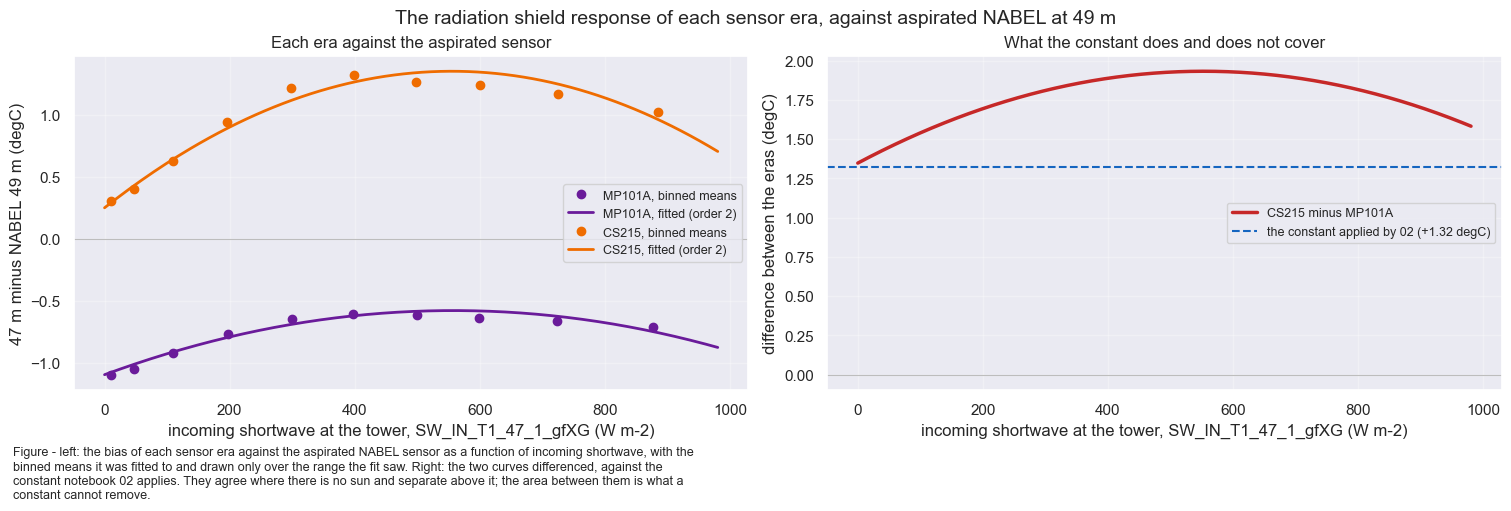

In [15]:
# The shield response, drawn against the binned data it was fitted to. The curves are drawn only
# over the range the fit actually saw - a polynomial beyond its data says nothing - and the binned
# means are placed at each bin's own mean radiation rather than at its centre.
_top = float(fitset[SWIN_COL].quantile(0.999))
_grid = np.linspace(0, _top, 200)

fig, axs = plt.subplots(ncols=2, figsize=(15, 5), dpi=100, layout="constrained")
fig.suptitle("The radiation shield response of each sensor era, against aspirated NABEL at 49 m",
             fontsize=14)

for _era, _colour in [('MP101A', '#6A1B9A'), ('CS215', '#EF6C00')]:
    _obs = binned_response(fitset[fitset['era'] == _era])
    axs[0].plot(_obs['sw'], _obs['bias'], 'o', color=_colour, ms=6, label=f"{_era}, binned means")
    axs[0].plot(_grid, shield_basis(_grid, SHIELD_ORDER) @ SHIELD[_era], '-', color=_colour, lw=2,
                label=f"{_era}, fitted (order {SHIELD_ORDER})")
axs[0].axhline(0, color='#BDBDBD', lw=0.8)
axs[0].set_xlabel(f"incoming shortwave at the tower, {SWIN_COL} (W m-2)")
axs[0].set_ylabel("47 m minus NABEL 49 m (degC)")
axs[0].set_title("Each era against the aspirated sensor")
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=9)

_diff = (shield_basis(_grid, SHIELD_ORDER) @ SHIELD['CS215']
         - shield_basis(_grid, SHIELD_ORDER) @ SHIELD['MP101A'])
print(f"curves drawn to {_top:.0f} W m-2, the 99.9th percentile of the radiation the fit saw")
axs[1].plot(_grid, _diff, color='#C62828', lw=2.5, label='CS215 minus MP101A')
axs[1].axhline(OFFSET, color='#1565C0', lw=1.5, ls='--',
               label=f"the constant applied by 02 ({OFFSET:+.2f} degC)")
axs[1].axhline(0, color='#BDBDBD', lw=0.8)
axs[1].set_xlabel(f"incoming shortwave at the tower, {SWIN_COL} (W m-2)")
axs[1].set_ylabel("difference between the eras (degC)")
axs[1].set_title("What the constant does and does not cover")
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=9)
figcap(fig, "left: the bias of each sensor era against the aspirated NABEL sensor as a function of "
            "incoming shortwave, with the binned means it was fitted to and drawn only over the "
            "range the fit saw. Right: the two curves differenced, against the constant notebook 02 "
            "applies. They agree where there is no sun and separate above it; the area between them "
            "is what a constant cannot remove.")
plt.show()

The left panel is the mechanism, measured. Both sensors read warm relative to the aspirated one as
radiation rises, and the CS215 rises more steeply. The MP101A curve sits about 1.3 °C lower
throughout, which is the zero-point error of the analog chain.

The right panel is the same two curves differenced, against the constant `02` applies. The two
agree where there is no sun, which is exactly what `02` derived the constant to do, and separate
above it. **The area between the two lines is the error the current product carries in daylight.**

### The two forms of candidate D

The fitted responses can be used in two ways, and the choice is not a technical one:

- **`D-aspirated`** subtracts each era's whole response, putting the record on the scale of an
  aspirated sensor. Best calibrated, but it rescales all twenty-one years onto another
  institution's instrument, and the column would no longer be what the 47 m sensor reported.
- **`D-shield`** keeps the constant of `02` and removes only the **radiation-dependent part** of
  the difference between the eras, standardising the CS215 era onto the MP101A era's shield
  behaviour. It is a strictly additive refinement of the current product: the night level, the
  evidence chain and the meaning of the column are unchanged.

Note what `D-shield` does **not** do: it does not remove the MP101A era's own shield error, which
both eras then carry. It makes the record self-consistent, not absolutely correct.

In [16]:
def apply_shield(coef, order, mode):
    """Return the corrected series. `mode` is 'aspirated' or 'shield' (see the text above)."""
    if mode not in ('aspirated', 'shield'):
        raise ValueError(f"unknown mode {mode!r}, expected 'aspirated' or 'shield'")
    _out = pd.Series(np.nan, index=d.index, name=f'D {mode}')
    for _era in ('MP101A', 'CS215'):
        _m = (d.index < BREAK) if _era == 'MP101A' else (d.index >= BREAK)
        _X = shield_basis(d.loc[_m, SWIN_COL], order)
        _X0 = shield_basis(np.zeros(int(_m.sum())), order)
        if mode == 'aspirated':
            _correction = _X @ coef[_era]
        else:
            # Only the radiative part of the era difference. The zero-radiation part is the
            # zero-point error that OFFSET already removes; subtracting it here as well would
            # correct the night twice.
            _correction = ((_X - _X0) @ coef[_era]) - ((_X - _X0) @ coef['MP101A'])
            _correction = _correction - (OFFSET if _era == 'MP101A' else 0.0)
        _out[_m] = d.loc[_m, 'measured'].to_numpy() - _correction
    return _out


candidates['D shield'] = apply_shield(SHIELD, SHIELD_ORDER, 'shield')
candidates['D aspirated'] = apply_shield(SHIELD, SHIELD_ORDER, 'aspirated')

# The guard guards: an unknown mode must raise rather than silently fall through to a default.
try:
    apply_shield(SHIELD, SHIELD_ORDER, 'asprated')
except ValueError as _e:
    print(f"apply_shield raises on a misspelt mode: {_e}")
else:
    raise AssertionError("apply_shield accepted an unknown mode")

# D-shield must leave the MP101A era exactly where B put it: this correction acts on the CS215
# era only, and a difference before the break would mean the radiative term is being applied twice.
_delta = (candidates['D shield'] - candidates['B constant offset']).dropna()
assert np.allclose(_delta[_delta.index < BREAK], 0.0, atol=1e-9), \
    "D-shield changed the MP101A era, which it is defined not to do"
_cs_delta = _delta[_delta.index >= BREAK]
print(f"\nD-shield changes the CS215 era by {_cs_delta.mean():+.3f} degC on average, ranging "
      f"from {_cs_delta.min():+.2f} to {_cs_delta.max():+.2f} degC, and the MP101A era not at all.")

apply_shield raises on a misspelt mode: unknown mode 'asprated', expected 'aspirated' or 'shield'

D-shield changes the CS215 era by -0.159 degC on average, ranging from -0.58 to +0.03 degC, and the MP101A era not at all.


### The three objections that had this option rejected

`02` records that a two-sided correction was costed and rejected, on three grounds: that the CS215
model could only be fitted on three years and would be applied over ten; that those ten years
contain a screen wiring fault in June 2022 and a shelter replacement in late 2025; and that a
correction resting on a gap-filled driver is not something the product should carry silently. Each
is now tested rather than argued.

In [17]:
# Objection 1 and 2: does the CS215 fit hold on the years NABEL never saw, and do the 2022 and
# 2025 events break it? Judged on the daytime residual against MeteoSwiss, per year.
_day = d['night'].to_numpy() == False
_per_year = {}
for _cand in ['B constant offset', 'D shield', 'D aspirated']:
    _r = (candidates[_cand] - d[REFCOL])[_day]
    _per_year[_cand] = _r.groupby(_r.index.year).mean()
per_year_day = pd.DataFrame(_per_year)
per_year_day['fitted against NABEL?'] = np.where(per_year_day.index <= NABEL_LAST_YEAR,
                                                 'in sample', 'OUT of sample')
per_year_day.index.name = 'YEAR'
tabcap("the daytime residual against MeteoSwiss per year, for the constant offset and for both forms of the shield correction. The years from 2019 are out of sample: NABEL had stopped, so nothing in them was used to fit anything")
display(per_year_day.round(2))

_early = per_year_day.loc[:BREAK.year - 1]
_ins = per_year_day.loc[BREAK.year:NABEL_LAST_YEAR]
_oos = per_year_day.loc[NABEL_LAST_YEAR + 1:]
_summary = pd.DataFrame({
    f'MP101A {_early.index.min()}-{_early.index.max()}': _early.iloc[:, :3].mean(),
    f'CS215 {_ins.index.min()}-{_ins.index.max()} (in sample)': _ins.iloc[:, :3].mean(),
    f'CS215 {_oos.index.min()}-{_oos.index.max()} (out of sample)': _oos.iloc[:, :3].mean(),
})
_summary['out of sample minus MP101A'] = _summary.iloc[:, 2] - _summary.iloc[:, 0]
tabcap("the same residual averaged over the MP101A era, the in-sample CS215 years and the out-of-sample CS215 years. The last column is the test of the extrapolation: under D the years NABEL never saw sit on the level of the MP101A era itself")
display(_summary.round(3))

# The decisive test of objection 1: the extrapolated years must land on the MP101A era's level,
# not merely somewhere better than B. They were never used to fit anything.
_gap = abs(_summary.loc['D shield', 'out of sample minus MP101A'])
_gap_b = abs(_summary.loc['B constant offset', 'out of sample minus MP101A'])
print(f"\nDaytime residual, out-of-sample years minus MP101A years:  "
      f"D-shield {_summary.loc['D shield', 'out of sample minus MP101A']:+.2f} degC   "
      f"B {_summary.loc['B constant offset', 'out of sample minus MP101A']:+.2f} degC")
assert _gap < _gap_b, (
    "the extrapolated CS215 years are no closer to the MP101A era under D than under B - the "
    "three-year fit does not generalise and candidate D must be reconsidered")
assert _gap < 0.15, f"the extrapolated years sit {_gap:.2f} degC from the MP101A era"

Table - the daytime residual against MeteoSwiss per year, for the constant offset and for both forms
of the shield correction. The years from 2019 are out of sample: NABEL had stopped, so nothing in
them was used to fit anything



,B constant offset,D shield,D aspirated,fitted against NABEL?
YEAR,,,,
2005,1.42,1.42,0.94,in sample
2006,1.28,1.28,0.80,in sample
2007,1.32,1.32,0.83,in sample
2008,1.34,1.34,0.85,in sample
2009,1.40,1.40,0.91,in sample
2010,1.49,1.49,1.01,in sample
2011,1.59,1.59,1.09,in sample
2012,1.60,1.60,1.12,in sample
2013,1.54,1.54,1.06,in sample


Table - the same residual averaged over the MP101A era, the in-sample CS215 years and the out-of-
sample CS215 years. The last column is the test of the extrapolation: under D the years NABEL never
saw sit on the level of the MP101A era itself



,MP101A 2005-2015,CS215 2016-2018 (in sample),CS215 2019-2025 (out of sample),out of sample minus MP101A
B constant offset,1.448,1.948,1.726,0.277
D shield,1.448,1.643,1.422,-0.027
D aspirated,0.961,1.123,0.901,-0.060



Daytime residual, out-of-sample years minus MP101A years:  D-shield -0.03 degC   B +0.28 degC


In [18]:
# Objection 2, resolved: the site events move B and D by the same amount, so what moves is the
# record, not the correction. If the CS215 fit were failing after 2022, D would drift and B
# would not.
_events = []
for _lo, _hi, _label in [(NABEL_LAST_YEAR + 1, 2021, 'before the Jun 2022 screen fault'),
                         (2022, 2024, 'after it, before the shelter replacement'),
                         (2025, int(per_year_day.index.max()), 'the shelter replacement year')]:
    _m = (per_year_day.index >= _lo) & (per_year_day.index <= _hi)
    if not _m.any():
        continue
    _events.append({'period': f"{_lo}-{_hi}  {_label}",
                    'B constant offset': per_year_day.loc[_m, 'B constant offset'].mean(),
                    'D shield': per_year_day.loc[_m, 'D shield'].mean()})
event_table = pd.DataFrame(_events).set_index('period')
event_table['D minus B'] = event_table['D shield'] - event_table['B constant offset']
tabcap("the daytime residual before and after the two site events the original rejection named. B and D move together, so what drifts is the record and not the extrapolated correction")
display(event_table.round(2))

_spread = event_table['D minus B'].max() - event_table['D minus B'].min()
print(f"\nThe correction D applies differs by only {_spread:.2f} degC across the three periods, so "
      f"the drift they share belongs to the record and not to the extrapolation.")
assert _spread < 0.15, (
    "the size of the D correction now varies across the site events - the extrapolation is no "
    "longer stable and objection 2 stands")

Table - the daytime residual before and after the two site events the original rejection named. B
and D move together, so what drifts is the record and not the extrapolated correction



,B constant offset,D shield,D minus B
period,,,
2019-2021 before the Jun 2022 screen fault,1.79,1.48,-0.31
"2022-2024 after it, before the shelter replacement",1.70,1.40,-0.30
2025-2025 the shelter replacement year,1.60,1.29,-0.31



The correction D applies differs by only 0.00 degC across the three periods, so the drift they share belongs to the record and not to the extrapolation.


In [19]:
# Objection 3: how much of the correction rests on a gap-filled SW_IN, and does it matter? The
# fit is repeated using only records whose radiation driver was measured.
_filled = d[SWIN_FLAG_COL] > 0
print(f"SW_IN gap-filled: {_filled.mean() * 100:.1f} % of the record, "
      f"{_filled[d.index >= BREAK].mean() * 100:.1f} % of the CS215 era")

_measured_only = fitset[d[SWIN_FLAG_COL].reindex(fitset.index) == 0]
print(f"fit rows on measured SW_IN only: {len(_measured_only):,} of {len(fitset):,}")
SHIELD_MEASURED = fit_shield(_measured_only, SHIELD_ORDER)
_alt = apply_shield(SHIELD_MEASURED, SHIELD_ORDER, 'shield')

_diff = (candidates['D shield'] - _alt).dropna()
print(f"Refitting on measured radiation only changes the corrected series by at most "
      f"{_diff.abs().max():.3f} degC (mean {_diff.abs().mean():.4f} degC).")
assert _diff.abs().max() < 0.1, (
    "the shield fit depends materially on gap-filled radiation - objection 3 stands and the "
    "correction would have to be restricted to measured records")

SW_IN gap-filled: 4.5 % of the record, 0.5 % of the CS215 era
fit rows on measured SW_IN only: 229,549 of 241,792
Refitting on measured radiation only changes the corrected series by at most 0.016 degC (mean 0.0011 degC).


***

## 5️⃣ Scorecard

Every candidate on the same criteria, all measured against MeteoSwiss, which enters none of them.
The two `D` forms are shown together: they differ in what they standardise onto, not in what they
remove.

In [20]:
SW_BINS = [0, 50, 100, 200, 300, 450, 600, 1200]

_rows = []
for _cand in candidates.columns:
    _r = (candidates[_cand] - d[REFCOL]).dropna()
    _row = {'candidate': _cand}
    for _wname, _wmask in [('night', _night_mask), ('day', _day_mask)]:
        _row[f'{BREAK.year} step, {_wname} (degC)'] = boundary_step(
            candidates[_cand], BREAK_PRE, BREAK_POST, _wmask)[2]
    _row[f'{NABEL_LAST_YEAR + 1} step, day (degC)'] = boundary_step(
        candidates[_cand], JOIN_PRE, JOIN_POST, _day_mask)[2]
    # The daytime era difference resolved by radiation: a candidate can have a small average step
    # and a large one in the bins that matter, which is what a mean over all daylight hides.
    _rr = (candidates[_cand] - d[REFCOL])
    _a = d.index.year.isin(BREAK_PRE) & (~d['night']).to_numpy()
    _b = d.index.year.isin(BREAK_POST) & (~d['night']).to_numpy()
    _prof = (_rr[_b].groupby(pd.cut(d.loc[_b, REFCOL_SW], SW_BINS), observed=False).mean()
             - _rr[_a].groupby(pd.cut(d.loc[_a, REFCOL_SW], SW_BINS), observed=False).mean())
    _row['largest step over the radiation bins (degC)'] = _prof.abs().max()
    _row['SD against MeteoSwiss (degC)'] = _r.std()
    _rows.append(_row)
scorecard = pd.DataFrame(_rows).set_index('candidate')
tabcap("every candidate on the same criteria, all measured against MeteoSwiss, which enters none of them. C trades a smaller step at 2016 for a larger one at its own join; both forms of D reduce the step and the radiation-resolved step without adding a boundary")
display(scorecard.round(2))

Table - every candidate on the same criteria, all measured against MeteoSwiss, which enters none of
them. C trades a smaller step at 2016 for a larger one at its own join; both forms of D reduce the
step and the radiation-resolved step without adding a boundary



,"2016 step, night (degC)","2016 step, day (degC)","2019 step, day (degC)",largest step over the radiation bins (degC),SD against MeteoSwiss (degC)
candidate,,,,,
A as measured,1.29,1.77,-0.16,2.16,1.20
B constant offset,-0.03,0.45,-0.16,0.84,0.94
C NABEL to 2018,-0.09,-0.03,0.67,0.09,0.93
D shield,-0.03,0.14,-0.16,0.33,0.90
D aspirated,-0.06,0.11,-0.16,0.30,0.86


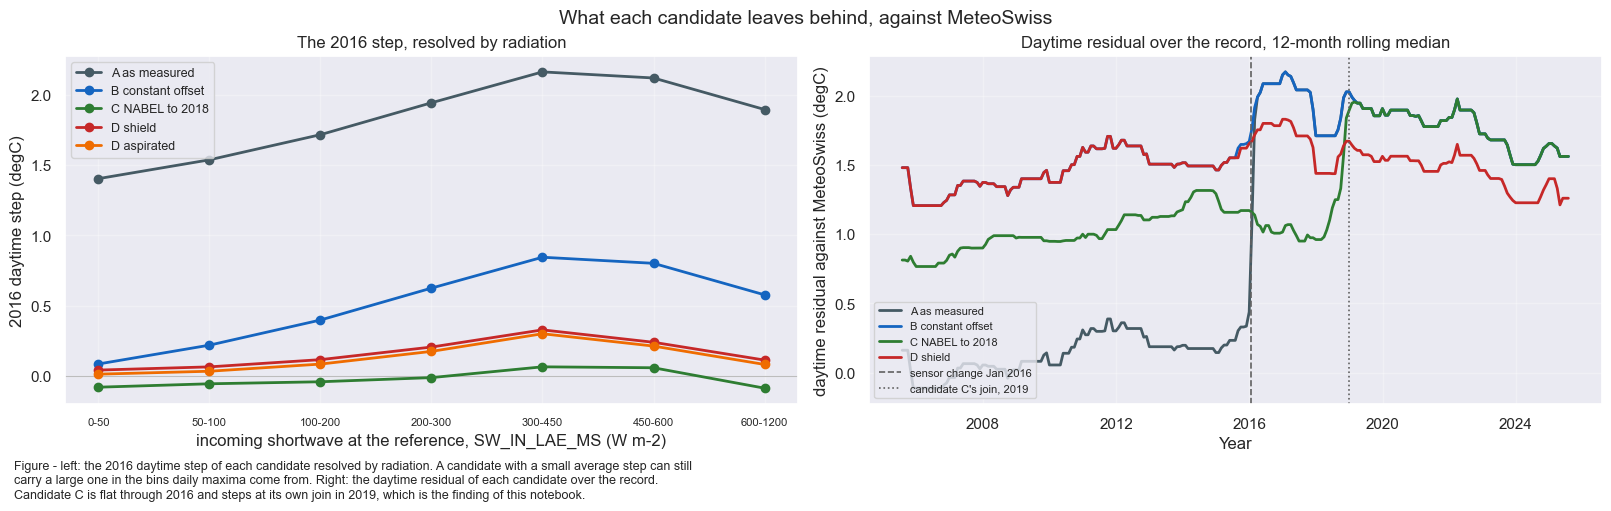

In [21]:
# The radiation profile behind the scorecard's fifth column, drawn.
fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout="constrained")
fig.suptitle("What each candidate leaves behind, against MeteoSwiss", fontsize=14)

_colours = {'A as measured': '#455A64', 'B constant offset': '#1565C0', 'C NABEL to 2018': '#2E7D32',
            'D shield': '#C62828', 'D aspirated': '#EF6C00'}
_x = np.arange(len(SW_BINS) - 1)
axs[0].axhline(0, color='#BDBDBD', lw=0.8)
for _cand in candidates.columns:
    _rr = (candidates[_cand] - d[REFCOL])
    _a = d.index.year.isin(BREAK_PRE) & (~d['night']).to_numpy()
    _b = d.index.year.isin(BREAK_POST) & (~d['night']).to_numpy()
    _prof = (_rr[_b].groupby(pd.cut(d.loc[_b, REFCOL_SW], SW_BINS), observed=False).mean()
             - _rr[_a].groupby(pd.cut(d.loc[_a, REFCOL_SW], SW_BINS), observed=False).mean())
    axs[0].plot(_x, _prof.to_numpy(), 'o-', color=_colours[_cand], lw=2, label=_cand)
axs[0].set_xticks(_x)
axs[0].set_xticklabels([f"{_a}-{_b}" for _a, _b in zip(SW_BINS[:-1], SW_BINS[1:])], fontsize=8)
axs[0].set_xlabel(f"incoming shortwave at the reference, {REFCOL_SW} (W m-2)")
axs[0].set_ylabel(f"{BREAK.year} daytime step (degC)")
axs[0].set_title("The 2016 step, resolved by radiation")
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=9)

for _cand in ['A as measured', 'B constant offset', 'C NABEL to 2018', 'D shield']:
    _m = (candidates[_cand] - d[REFCOL])[(~d['night']).to_numpy()].resample('ME').mean()
    axs[1].plot(_m.index, _m.rolling(12, center=True).median(), color=_colours[_cand], lw=2,
                label=_cand)
axs[1].axvline(BREAK, color='#616161', lw=1.2, ls='--', label=f"sensor change {BREAK:%b %Y}")
axs[1].axvline(pd.Timestamp(f'{NABEL_LAST_YEAR + 1}-01-01'), color='#616161', lw=1.2, ls=':',
               label=f"candidate C's join, {NABEL_LAST_YEAR + 1}")
axs[1].set_xlabel("Year")
axs[1].set_ylabel("daytime residual against MeteoSwiss (degC)")
axs[1].set_title("Daytime residual over the record, 12-month rolling median")
axs[1].grid(alpha=0.3)
axs[1].legend(fontsize=8, loc='lower left')
figcap(fig, "left: the 2016 daytime step of each candidate resolved by radiation. A candidate with "
            "a small average step can still carry a large one in the bins daily maxima come from. "
            "Right: the daytime residual of each candidate over the record. Candidate C is flat "
            "through 2016 and steps at its own join in 2019, which is the finding of this notebook.")
plt.show()

***

## 6️⃣ Conclusion

**Candidate C — NABEL until 2018, then the homogenised 47 m — is rejected.** It removes the 2016
daytime step and creates a larger one at its own join, because an aspirated sensor differs from
both 47 m sensors by more than they differ from each other. It also renames fourteen years of the
column after a different institution's instrument, and cannot cover the record because NABEL ends.
The premise that prompted it is nevertheless correct, and is what makes candidate `D` possible:
NABEL is the aspirated standard against which a shield error can be measured at all.

**Candidate D is supported.** Fitting each era's shield response against NABEL and removing the
radiative part of the difference between them reduces the daytime step and the largest
radiation-resolved step by roughly a factor of three, adds no new boundary, and improves the
scatter against an independent station. The three objections recorded in `02` were tested here,
not argued: the three-year CS215 fit lands the extrapolated years on the MP101A era's own level;
the June 2022 and late 2025 events move `B` and `D` by the same amount, so what drifts is the
record; and the gap-filled radiation driver changes the correction by an amount too small to
matter.

**Of the two forms, `D-shield` is the one to adopt**, and version 7 of `02` adopts it. It keeps
the constant `02` derives, changes only the CS215 era, and leaves the column meaning what its name
says. `D-aspirated` scores better on every criterion, and it is the right choice only if the product
is meant to be an aspirated-standard series rather than a record of this sensor — a different
decision from the one this notebook is about.

**What is still not fixed.** `D-shield` standardises the CS215 era onto the MP101A era's shield
behaviour, and the MP101A era's own shield error remains in both. Daily maxima and diurnal ranges
therefore stay biased warm relative to an aspirated measurement across the whole record; what
changes is that they stop being biased *differently* on the two sides of 2016.

### What adopting `D-shield` required in notebook `02`

Recorded here so that the change is a decision rather than a rediscovery. Nothing in this notebook
writes to the product; `02` re-derives the shield term itself, on its own fit set, and exports it.
Its numbers differ slightly from the ones here because it fits on every record it has, while this
notebook restricts every comparison to complete years.

- `02` gains a dependency on the `SW_IN` product it already loads as a gap-filling driver, and on
  the NABEL download it already performs. No new data source.
- The correction is a function of radiation, so it must be applied **after** gap-filling and to
  modelled records as well, using the same driver the model used.
- A third exported column, or a change of what `TA_T1_47_1_HOMOGENIZED_gfXG` means. Changing the
  existing column silently would alter a published series; a new one costs a column and is honest.
- The *What the correction does not fix* section of `02` would lose its first item and gain the
  narrower one stated above.

***

## End of notebook.

In [22]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h}h {_m}m {_s}s")

Started:  2026-07-28 17:47:18
Finished: 2026-07-28 17:47:35
Runtime:  0h 0m 17s
